In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels.api as sm


In [12]:
# 1. LOAD DATA
df = pd.read_csv('/data/birthwt.csv')

Correlation Age vs BWT: 0.0903
Correlation LWT vs BWT: 0.1857


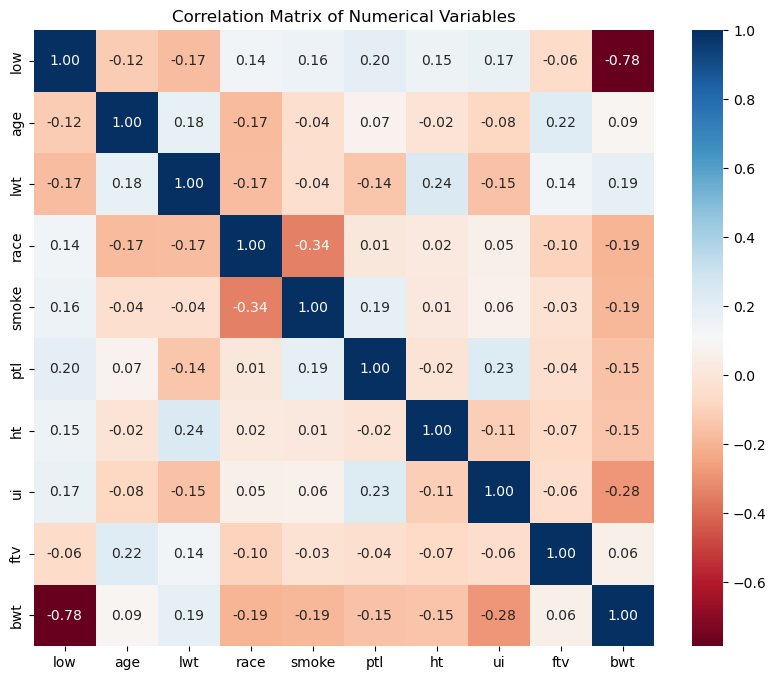

In [6]:
# 2. EXPLORATORY CORRELATION
# Replicating: cor(age, bwt) and cor(lwt, bwt)
corr_age = df['age'].corr(df['bwt'])
corr_lwt = df['lwt'].corr(df['bwt'])
print(f"Correlation Age vs BWT: {corr_age:.4f}")
print(f"Correlation LWT vs BWT: {corr_lwt:.4f}")

# Replicating: pairs(birthwt) using a Heatmap for clarity
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()



In [7]:
# 3. MULTIPLE REGRESSION MODELING
# Replicating 'bwt.fit2': bwt ~ lwt + race + smoke + ptl + ht + ui
# C() tells statsmodels to treat the variable as Categorical (Factor)
formula = 'bwt ~ lwt + C(race) + C(smoke) + C(ptl) + C(ht) + C(ui)'
model = smf.ols(formula=formula, data=df).fit()

# Display the summary (Matches R's summary(bwt.fit2) output)
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                    bwt   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     7.534
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.50e-09
Time:                        21:09:38   Log-Likelihood:                -1483.2
No. Observations:                 189   AIC:                             2986.
Df Residuals:                     179   BIC:                             3019.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2834.3236    241.596     11.732


Shapiro-Wilk Test p-value: 0.4973
Breusch-Pagan Test p-value: 0.7374


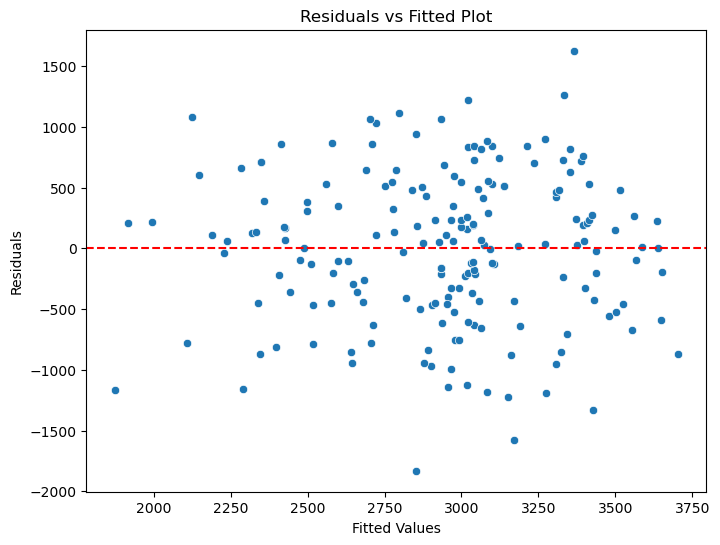

In [9]:
# 4. STATISTICAL DIAGNOSTICS

# a. Normality of Residuals (Shapiro-Wilk Test)
# H0: Residuals are normally distributed
shapiro_p = stats.shapiro(model.resid)[1]
print(f"\nShapiro-Wilk Test p-value: {shapiro_p:.4f}")

# b. Homoscedasticity (Breusch-Pagan Test / NCV substitute)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.4f}")

# c. Residual Plot (Visualizing error distribution)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Plot")
plt.show()



In [10]:
# 5. MODEL APPLICATION (PREDICTION)
# Replicating the prediction for record #7 (index 6)
target_obs = df.iloc[[6]]
prediction = model.get_prediction(target_obs)
frame = prediction.summary_frame(alpha=0.05) # 95% Confidence Interval

print("\nPrediction for record #7:")
print(f"Predicted Value: {frame['mean'].values[0]:.2f}")
print(f"95% PI: ({frame['obs_ci_lower'].values[0]:.2f}, {frame['obs_ci_upper'].values[0]:.2f})")
print(f"Actual Value: {df.iloc[6]['bwt']}")


Prediction for record #7:
Predicted Value: 3342.39
95% PI: (2073.57, 4611.21)
Actual Value: 2637
